# Practical 05_a: Object Detection using R-CNN and Faster R-CNN Comparison


## Load Pre-Trained PyTorch Model (Faster R-CNN with ResNet50 Backbone)

In [146]:
import os
import time
import torch
import kagglehub
import pandas as pd

from PIL import Image

from torchvision import transforms

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    ssdlite320_mobilenet_v3_large
)

In [147]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [148]:
root = kagglehub.dataset_download("ultralytics/coco128")

img_dir = find_image_dir(root)

image_paths = [
    os.path.join(img_dir, f)
    for f in os.listdir(img_dir)
    if f.lower().endswith((".jpg", ".png"))
][:50]

print("Loaded images:", len(image_paths))

Using Colab cache for faster access to the 'coco128' dataset.
Loaded images: 50


In [149]:
print("Loading Faster R-CNN...")

frcnn = fasterrcnn_resnet50_fpn(
    weights="DEFAULT"
).to(device).eval()

print("Loading SSD Lite...")

ssd = ssdlite320_mobilenet_v3_large(
    weights="DEFAULT"
).to(device).eval()

print("Models loaded successfully.")

Loading Faster R-CNN...
Loading SSD Lite...
Models loaded successfully.


In [150]:
transform = transforms.ToTensor()

In [151]:
root = kagglehub.dataset_download(
    "ultralytics/coco128"
)

print("Dataset root:")
print(root)

Using Colab cache for faster access to the 'coco128' dataset.
Dataset root:
/kaggle/input/coco128


In [152]:
def find_image_dir(root_dir):

    for path, dirs, files in os.walk(root_dir):

        if any(
            f.lower().endswith((".jpg", ".jpeg", ".png"))
            for f in files
        ):
            return path

    return None


img_dir = find_image_dir(root)

print("Image directory:")
print(img_dir)

Image directory:
/kaggle/input/coco128/coco128/images/train2017


In [153]:
image_paths = sorted([
    os.path.join(img_dir, f)
    for f in os.listdir(img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])[:50]

print("Loaded images:", len(image_paths))

Loaded images: 50


In [154]:
@torch.no_grad()
def predict(model, img_tensor):

    output = model([
        img_tensor.to(device)
    ])[0]

    return output

In [155]:
def benchmark(model, image_paths, model_name):

    total_detections = 0
    total_confidence = 0
    total_time = 0

    print(f"\nRunning benchmark for {model_name}...")

    for idx, path in enumerate(image_paths):

        # Load image
        img = Image.open(path).convert("RGB")

        tensor = transform(img)

        # Timing
        start_time = time.time()

        output = predict(model, tensor)

        end_time = time.time()

        inference_time = end_time - start_time

        total_time += inference_time

        # Scores
        scores = output["scores"].cpu()

        keep = scores > 0.5

        detections = keep.sum().item()

        total_detections += detections

        if detections > 0:
            total_confidence += scores[
                keep
            ].sum().item()

        print(
            f"[{idx+1:02d}/{len(image_paths)}] "
            f"{model_name} | "
            f"Detections: {detections}"
        )

    # Final metrics
    avg_confidence = (
        total_confidence /
        max(total_detections, 1)
    )

    avg_inference_time = (
        total_time /
        len(image_paths)
    )

    fps = 1 / avg_inference_time

    results = {
        "Model": model_name,
        "Total Detections": total_detections,
        "Average Confidence": round(avg_confidence, 3),
        "Average Inference Time (s)": round(avg_inference_time, 4),
        "FPS": round(fps, 2)
    }

    return results

In [ ]:
ssd_results = benchmark(
    ssd,
    image_paths,
    "SSD Lite"
)

In [ ]:
print("=" * 60)
print("FINAL VERDICT")
print("=" * 60)

# Quality winner
if (
    frcnn_results["Average Confidence"] >
    ssd_results["Average Confidence"]
):
    print(
        "🏆 Faster R-CNN performs better "
        "in confidence/stability."
    )
else:
    print(
        "🏆 SSD Lite performs better "
        "in confidence."
    )

# Speed winner
if (
    frcnn_results["FPS"] >
    ssd_results["FPS"]
):
    print(
        "⚡ Faster R-CNN is faster."
    )
else:
    print(
        "⚡ SSD Lite is significantly faster."
    )

In [160]:
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle',
    'airplane', 'bus', 'train', 'truck', 'boat',
    'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear',
    'zebra', 'giraffe', 'backpack', 'umbrella',
    'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle',
    'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote',
    'keyboard', 'cell phone', 'microwave', 'oven',
    'toaster', 'sink', 'refrigerator', 'book',
    'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

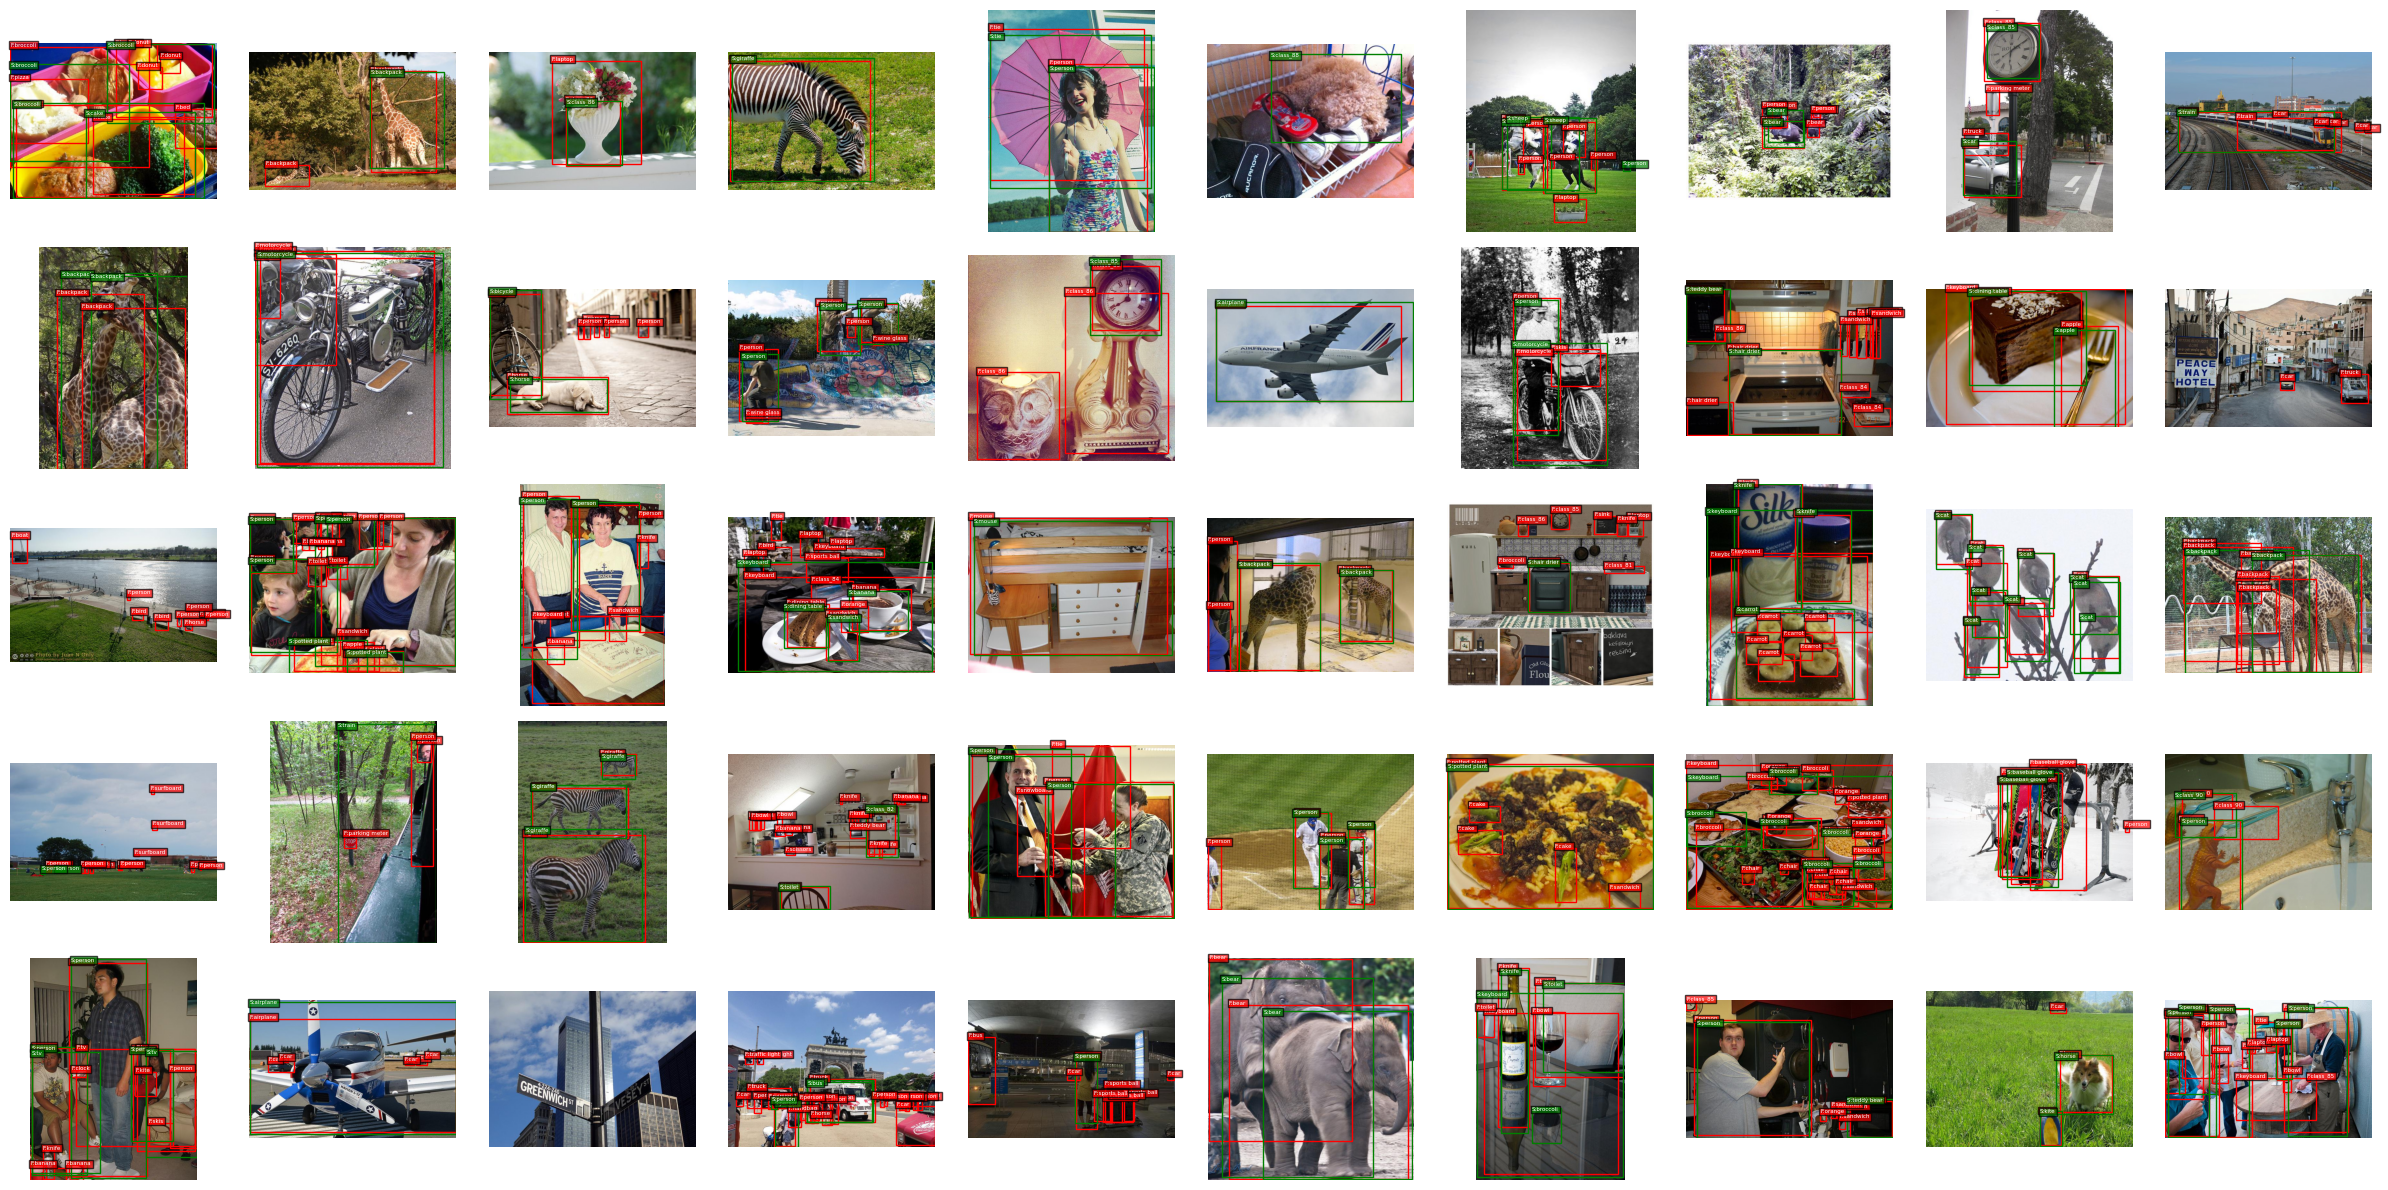

In [163]:
fig, axes = plt.subplots(
    5,
    10,
    figsize=(24, 12)
)

axes = axes.flatten()

for idx, image_path in enumerate(image_paths):

    ax = axes[idx]

    # Load image
    img = Image.open(image_path).convert("RGB")

    tensor = transform(img)

    # Predictions
    frcnn_out = predict(frcnn, tensor)

    ssd_out = predict(ssd, tensor)

    # Show image
    ax.imshow(img)

    ax.axis("off")

    # =====================================
    # Faster R-CNN (RED)
    # =====================================
    for box, label, score in zip(
        frcnn_out["boxes"],
        frcnn_out["labels"],
        frcnn_out["scores"]
    ):

        if score > 0.7:

            x1, y1, x2, y2 = (
                box.cpu().numpy()
            )

            label_idx = label.item()

            if label_idx < len(COCO_CLASSES):
                label_name = COCO_CLASSES[label_idx]
            else:
                label_name = f"class_{label_idx}"

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=1,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1,
                f"F:{label_name}",
                fontsize=4,
                color="white",
                bbox=dict(
                    facecolor="red",
                    alpha=0.7,
                    pad=1
                )
            )

    # =====================================
    # SSD (GREEN)
    # =====================================
    for box, label, score in zip(
        ssd_out["boxes"],
        ssd_out["labels"],
        ssd_out["scores"]
    ):

        if score > 0.5:

            x1, y1, x2, y2 = (
                box.cpu().numpy()
            )

            label_idx = label.item()

            if label_idx < len(COCO_CLASSES):
                label_name = COCO_CLASSES[label_idx]
            else:
                label_name = f"class_{label_idx}"

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=1,
                edgecolor="green",
                facecolor="none"
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1 + 8,
                f"S:{label_name}",
                fontsize=4,
                color="white",
                bbox=dict(
                    facecolor="green",
                    alpha=0.7,
                    pad=1
                )
            )

plt.tight_layout()

plt.show()

In [164]:
frcnn_total_det = 0
frcnn_total_conf = 0

ssd_total_det = 0
ssd_total_conf = 0

for image_path in image_paths:

    img = Image.open(image_path).convert("RGB")

    tensor = transform(img)

    # Predictions
    frcnn_out = predict(frcnn, tensor)

    ssd_out = predict(ssd, tensor)

    # =====================================
    # Faster R-CNN metrics
    # =====================================
    frcnn_scores = frcnn_out["scores"].cpu()

    frcnn_keep = frcnn_scores > 0.7

    frcnn_det = frcnn_keep.sum().item()

    frcnn_total_det += frcnn_det

    if frcnn_det > 0:
        frcnn_total_conf += (
            frcnn_scores[frcnn_keep]
            .sum()
            .item()
        )

    # =====================================
    # SSD metrics
    # =====================================
    ssd_scores = ssd_out["scores"].cpu()

    ssd_keep = ssd_scores > 0.5

    ssd_det = ssd_keep.sum().item()

    ssd_total_det += ssd_det

    if ssd_det > 0:
        ssd_total_conf += (
            ssd_scores[ssd_keep]
            .sum()
            .item()
        )

# =====================================
# FINAL METRICS
# =====================================
frcnn_avg_conf = (
    frcnn_total_conf /
    max(frcnn_total_det, 1)
)

ssd_avg_conf = (
    ssd_total_conf /
    max(ssd_total_det, 1)
)

# =====================================
# PRINT RESULTS
# =====================================
print("=" * 50)
print("FINAL METRIC COMPARISON")
print("=" * 50)

print("\nFaster R-CNN")
print("-------------------")
print("Total detections:", frcnn_total_det)
print("Average confidence:", round(frcnn_avg_conf, 3))

print("\nSSD Lite")
print("-------------------")
print("Total detections:", ssd_total_det)
print("Average confidence:", round(ssd_avg_conf, 3))

print("\n" + "=" * 50)
print("FINAL VERDICT")
print("=" * 50)

# Confidence winner
if frcnn_avg_conf > ssd_avg_conf:

    print(
        "🏆 Faster R-CNN has higher confidence detections"
    )

else:

    print(
        "🏆 SSD Lite has higher confidence detections"
    )

# Detection winner
if frcnn_total_det > ssd_total_det:

    print(
        "📦 Faster R-CNN detected more objects"
    )

else:

    print(
        "📦 SSD Lite detected more objects"
    )

FINAL METRIC COMPARISON

Faster R-CNN
-------------------
Total detections: 346
Average confidence: 0.907

SSD Lite
-------------------
Total detections: 118
Average confidence: 0.828

FINAL VERDICT
🏆 Faster R-CNN has higher confidence detections
📦 Faster R-CNN detected more objects
